In [19]:
import pandas as pd 
df = pd.read_csv("/home/susan/battery-rul-llm-project/data/raw/Battery_dataset.csv")
print(df.head())

  battery_id  cycle       chI       chV        chT      disI      disV  \
0         B5      1  1.440147  4.254682  23.988733  1.894407  3.273523   
1         B5      2  1.416595  4.159825  25.665347  1.829949  4.038741   
2         B5      3  1.420272  4.276323  25.407910  1.942105  3.214433   
3         B5      4  1.337680  4.236697  27.069757  2.073577  3.134529   
4         B5      5  1.263946  4.142791  26.478353  2.049885  3.729341   

        disT       BCt        SOH  RUL  
0  32.980834  1.986196  99.309790  219  
1  32.257920  1.986240  99.311985  218  
2  35.134801  1.984252  99.212608  217  
3  32.082988  1.969236  98.461812  216  
4  32.483154  1.974862  98.743106  215  


In [14]:
# chack shape of the data
print(df.shape)
#check tail of the data
print(df.tail())
# check the columns of the data
print(df.columns)
# check the data types of the columns
print(df.dtypes)    
# check for description of the data
print(df.describe())    


(680, 11)
    battery_id  cycle       chI       chV        chT      disI      disV  \
675         B7    246  1.381406  4.210231  25.510877  2.037612  3.298042   
676         B7    247  1.428183  4.209903  28.080145  1.972805  3.698309   
677         B7    248  1.345410  4.214256  29.098463  1.967716  3.942091   
678         B7    249  1.407450  4.184595  26.736025  1.979535  3.025646   
679         B7    250  1.406368  4.186322  28.726130  1.886375  3.424952   

          disT       BCt        SOH  RUL  
675  34.281706  0.761970  38.098522    4  
676  30.898516  0.765903  38.295138    3  
677  30.828397  0.762010  38.100506    2  
678  32.303220  0.757444  37.872193    1  
679  33.988588  0.750972  37.548593    0  
Index(['battery_id', 'cycle', 'chI', 'chV', 'chT', 'disI', 'disV', 'disT',
       'BCt', 'SOH', 'RUL'],
      dtype='str')
battery_id        str
cycle           int64
chI           float64
chV           float64
chT           float64
disI          float64
disV          float6

In [16]:
# Check for missing values
print(df.isnull().sum())    

battery_id    0
cycle         0
chI           0
chV           0
chT           0
disI          0
disV          0
disT          0
BCt           0
SOH           0
RUL           0
dtype: int64


In [8]:
#fordulicated values
print(df.duplicated().sum())

0


In [17]:
# handeling text data
df.columns = (df.columns.str.strip() 
                        .str.replace(" ", "_"))
print(df.columns)


Index(['battery_id', 'cycle', 'chI', 'chV', 'chT', 'disI', 'disV', 'disT',
       'BCt', 'SOH', 'RUL'],
      dtype='str')


In [ ]:
# Import libraries
import pandas as pd

from sklearn.model_selection import train_test_split
# Load dataset
df = pd.read_csv("/home/susan/battery-rul-llm-project/data/processed/battery_cleaned.csv")


In [15]:
# Create features (all columns except target)
features = df.drop('RUL', axis=1)

# Create target
target = df['RUL']

# Step 1:
# Split into temporary data (80%)
# and test data (20%)

X_temp, X_test, y_temp, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)
# Step 2:
# Split temporary data into:
# training set (60% total)
# validation set (20% total)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42
)
# Check shapes

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (408, 10)
y_train: (408,)
X_val: (136, 10)
y_val: (136,)
X_test: (136, 10)
y_test: (136,)


In [23]:
X_train.dtypes
# Find text columns
text_columns = X_train.select_dtypes(include="object").columns

print(text_columns)

Index(['battery_id'], dtype='str')


/tmp/ipykernel_72029/163533743.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = X_train.select_dtypes(include="object").columns


In [24]:
# Remove text columns
X_train = X_train.drop(columns=text_columns)
X_val = X_val.drop(columns=text_columns)
X_test = X_test.drop(columns=text_columns)

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np  
# Create the model = RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)    
# Train the model
model.fit(X_train, y_train)
# Predict on validation set
y_val_pred = model.predict(X_val)
# Evaluate the model
mae = mean_absolute_error(y_val, y_val_pred)
mse = mean_squared_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)
rmse = np.sqrt(mse)
print(f"Validation MAE: {mae}")
print(f"Validation MSE: {mse}")
print(f"Validation R^2: {r2}")  
print(f"Validation RMSE: {rmse}")    

Validation MAE: 16.54654411764706
Validation MSE: 345.4543463235294
Validation R^2: 0.9263784631062288
Validation RMSE: 18.58640218879193


In [27]:
# Create the model #2 = Linear Regression model
# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Import evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Import numpy for RMSE calculation
import numpy as np


# -------------------------------
# Model 1: Linear Regression
# -------------------------------

# Create the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Predict on validation dataset
y_val_pred_lr = linear_model.predict(X_val)

# -------------------------------
# Evaluate the model
# -------------------------------

# Mean Absolute Error
mae_lr = mean_absolute_error(y_val, y_val_pred_lr)

# Mean Squared Error
mse_lr = mean_squared_error(y_val, y_val_pred_lr)

# Root Mean Squared Error
rmse_lr = np.sqrt(mse_lr)

# R² Score
r2_lr = r2_score(y_val, y_val_pred_lr)

# -------------------------------
# Print results
# -------------------------------

print("Linear Regression Results")
print("----------------------------")

print(f"Validation MAE: {mae_lr}")

print(f"Validation MSE: {mse_lr}")

print(f"Validation RMSE: {rmse_lr}")

print(f"Validation R²: {r2_lr}")

Linear Regression Results
----------------------------
Validation MAE: 16.880112301779864
Validation MSE: 324.0168822395831
Validation RMSE: 18.000468944990935
Validation R²: 0.9309471103667472


In [28]:
# Import Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

# Import evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Import numpy for RMSE calculation
import numpy as np


# -----------------------------------
# Model 3: Gradient Boosting Regressor
# -----------------------------------

# Create the model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)

# Predict on validation dataset
y_val_pred_gb = gb_model.predict(X_val)

# -----------------------------------
# Evaluate the model
# -----------------------------------

# Mean Absolute Error
mae_gb = mean_absolute_error(y_val, y_val_pred_gb)

# Mean Squared Error
mse_gb = mean_squared_error(y_val, y_val_pred_gb)

# Root Mean Squared Error
rmse_gb = np.sqrt(mse_gb)

# R² Score
r2_gb = r2_score(y_val, y_val_pred_gb)

# -----------------------------------
# Print results
# -----------------------------------

print("Gradient Boosting Regressor Results")
print("-------------------------------------")

print(f"Validation MAE: {mae_gb}")

print(f"Validation MSE: {mse_gb}")

print(f"Validation RMSE: {rmse_gb}")

print(f"Validation R²: {r2_gb}")

Gradient Boosting Regressor Results
-------------------------------------
Validation MAE: 16.54665909963087
Validation MSE: 353.93655343758786
Validation RMSE: 18.81320157329921
Validation R²: 0.9245707767053074


  Feature  Importance
7     BCt    0.423027
8     SOH    0.321517
0   cycle    0.210667
1     chI    0.007957
5    disV    0.007826
3     chT    0.007590
4    disI    0.007376
2     chV    0.007085
6    disT    0.006955


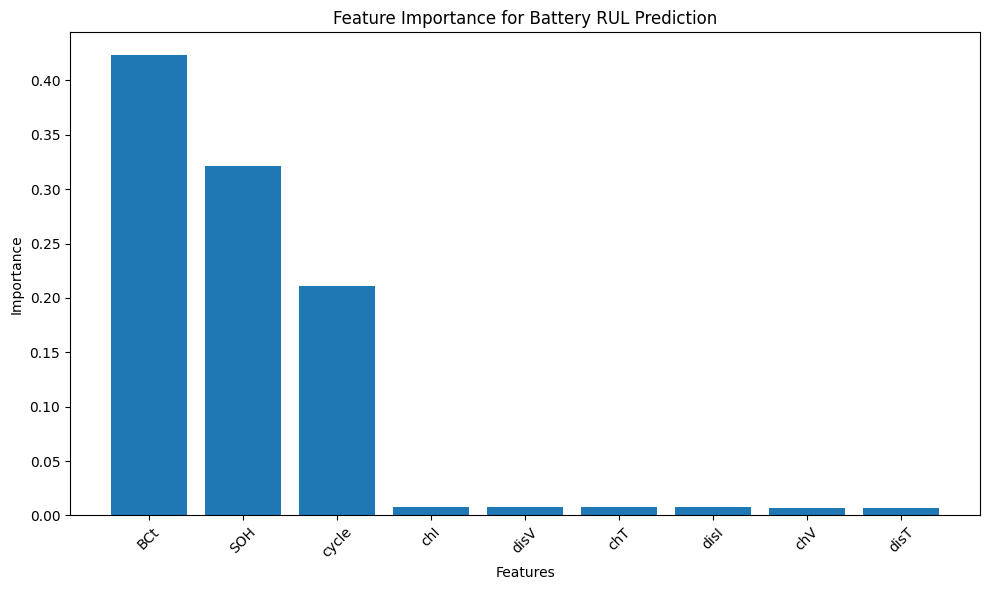

In [29]:
# Create feature importance dataframe

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Show results
print(feature_importance)

import matplotlib.pyplot as plt

# Plot feature importance

plt.figure(figsize=(10,6))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xticks(rotation=45)

plt.xlabel("Features")
plt.ylabel("Importance")

plt.title("Feature Importance for Battery RUL Prediction")

plt.tight_layout()

plt.show()